In [4]:
import baltic as bt
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import itertools
import re
import sys
import pprint
import statistics
from datetime import datetime, timedelta, date
import numpy as np
from plotnine import *
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import plotly.express as px

In [5]:
def load_tree(nexusPath):
    mytree = bt.loadNexus(nexusPath, tip_regex='\|([0-9]{4}\-[0-9]{2}\-[0-9]{2})', absoluteTime=True, verbose=False) # your tip regex might have to change or you could convert you tree into a newick by deleting everything before the tree string lol
    return(mytree)

In [6]:
nexusPath = "../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_MCC.tree"

In [7]:
tree = load_tree(nexusPath)

In [8]:
tree.treeStats()


Tree height: 6.003206
Tree length: 113.765981
strictly bifurcating tree

Numbers of objects in tree: 723 (361 nodes and 362 leaves)



In [11]:
# Use this code to print some info if you want it

count = 0

for k in tree.Objects:
    if count < 10:
        if k.is_node():
            count += 1
            print(k.absoluteTime)

2020.048849270397
2021.083493163454
2021.1306878662592
2021.387224264426
2021.4619137743098
2021.4910504729464
2021.5374680799925
2021.5257025966043
2021.9384889220428
2022.622821400785


In [39]:
flyway_colors = {
    "AtlanticFlyway":"#AA7722",
    "MississippiFlyway":"#5E9B82",
    "CentralFlyway":"#C593D1",
    "PacificFlyway":"#2B57B3"
}

h5n1_order_colors = {"accipitriformes":"#C593D1",
               "strigiformes":"#C593D1", 
               "anseriformes":"#2B57B3",
               "charadriiformes":"#AA7722",
               "pelecaniformes":"#AA7722",
               "passeriformes":"#5E9B82",
               "falconiformes":"#5E9B82",
               "suliformes":"#5E9B82",
               "podicipediformes":"#5E9B82",
               "galliformes":"#5E9B82",
               "columbiformes":"#5E9B82",
               "gruiformes":"#5E9B82",
               "gaviiformes":"#5E9B82",
               "ciconiiformes":"#5E9B82",
               "apodiformes":"#5E9B82",
               "unknown":"#5E9B82",
               "casuariiformes":"#5E9B82",
               "other":"#5E9B82"
              }

h5n5_host_colors = {"seab":"#6AA1F4",
          "bdpr":"#F69BA6",
          "gds":"#6A994E",
          "mammal":"#A874D2",
          "scav":"#923E4D",
          "grdbd":"#E9C46A"
 #         "other":"#95A8B0"
         }

h5n1_host_colors = {"bird-of-prey":"#C43110", # red-maroon
                     "duck":"#679C48", # green 
                     "goose-swan": "#DBB730", # yellow
                     "shorebird":"#68A0A6", # blue
                     "songbird-etc":"#D9A7B0", # pink
                     "ground-bird":"#E08907", # orange
                     "diving-bird":"#503A63", # deep purple
                     "other":"#A0A0A3" # grey
                    }

h5n5_region_colors = {"europe":"#ffaaaa",
          "east-canada":"#95b8d1",
          "northeast-us":"#f7df7d",
          "north-canada":"#ba9cc9",
          "northwest-us":"#94bf73",
          "asia":"#b09a6e"
         }

In [40]:
labels = {"seab":"Seabirds and Shorebirds",
          "bdpr":"Birds of Prey",
          "gds":"Geese, ducks, and seaducks",
          "mammal":"Mammals",
          "scav":"Scavengers",
          "grdbd":"Ground birds"
         # "other":"#95A8B0"
         }

# labels = {"europe":"Europe",
#           "east-canada":"Eastern Canada",
#           "new-england":"New England",
#           "north-canada":"Northern Canada",
#           "pacific-northwest":"Pacific Northwest (USA)",
#           "asia":"Asia"
#          }

# labels = {"bird-of-prey":"Bird of Prey", # red-maroon
#                      "duck":"Duck", # green 
#                      "goose-swan": "Goose or Swan", # yellow
#                      "shorebird":"Shorebird or Seabird", # blue
#                      "songbird-etc":"Songbird (including corvids)", # pink
#                      "ground-bird":"Ground Bird", # orange
#                      "diving-bird":"Diving Bird", # deep purple
#                      "other":"Other" # grey
#                     }

In [53]:
def plot_tree(traitName, tree, MRSD, save_path, colors, fig_size=(20, 20)):

    # origin_shape = {"europe":"s","east-canada":"^","new-england":"^","north-canada":"^","pacific-northwest":"^","asia":"v"}

    c_func = lambda k: colors.get(k.traits[traitName], 'grey') # Color function based on traits

    tipSize = 30

    # s_func = lambda k: origin_shape.get(k.traits["region"], "o") # set the shape based on the continent, default is circle
    s_func = "o" # set the shape based on the continent, default is circle

    w_func = lambda k: 1.75 + (len(k.leaves) * 0.0025) if k.is_node() else 1.25

    y_func = lambda k: k.y

    # Initialize figure and cumulative y offset
    fig = plt.figure(figsize=fig_size, facecolor='w')
    gs = gridspec.GridSpec(1, 1, wspace=0.0)
    ax = plt.subplot(gs[0], facecolor='w')

    most_recent_sampling_date = MRSD
            
    for k in tree.Objects: 
        x = k.absoluteTime
        y =  y_func(k)
        s = tipSize
        xp = k.parent.absoluteTime
        
        # if x==None: # If no "height", then x = 0
        #     x=0.0
        
        # if k.parent.absoluteTime != None: # if the parent has a "height"
        #     xp = k.parent.absoluteTime
        # else: 
        #     xp = 0.0 # else, x coordinate is 0?

        if k.branchType == "leaf": 
            c = c_func(k)
            ax.scatter(x,y,s=s,facecolor=c,edgecolor='none',zorder=11) # plot circle for every tip
            ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='none',zorder=10) # plot black circle underneath
            ax.plot([xp,x],[y,y],color=c,ls='-',zorder=9)
        
        elif k.branchType == "node": # this more or less plots branches WITHOUT points for each node
            # n_children = len(k.leaves)
            ax.plot([x,x], [y_func(k.children[-1]), y_func(k.children[0])], color = c_func(k), zorder = 9, lw = w_func(k)) # plot the vertical line connecting nodes
            ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9, lw = w_func(k)) # plot the horizontal line connecting node
            
    # Axis and plot styling
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    ax.tick_params(axis='x', size=0, labelsize=25)
    ax.tick_params(axis='y', size=0)
    ax.grid(axis='x', ls='--')
    
    
    # Set y-axis limits and remove labels
    ax.set_yticklabels([])
    ax.set_ylim(-15, max(k.y for k in tree.Objects) + 15)
    
    # Determine the min and max dates in the tree
    min_date = min((k.absoluteTime for k in tree.Objects if k.is_node()))
    max_date = max(k.absoluteTime for k in tree.Objects if k.is_node())

    # Add in dashed lines at the midpoints as well
    xticks = ax.get_xticks()
    midpoints = np.mean([xticks[:-1], xticks[1:]], axis=0)
    ax.vlines(midpoints, *ax.get_ylim(), linestyles='--', colors='gray', linewidth = 0.8, alpha = 0.4)
    
    # Set x-axis limits with some padding
    padding = 0.3  # Adjust padding as desired
    ax.set_xlim(min_date - padding, max_date + padding)    
    
    # Legend setup
    # handles = [
    #     plt.Line2D([0], [0], marker='o', color='w', label=label,
    #                markersize=15, markerfacecolor=color)
    #     for label, color in colors.items()
    # ]
    # for h in handles: # add different labels
    #     h.set_label(labels.get(h.get_label(), h.get_label()))
        
    # plt.legend(handles=handles, title='Region', loc=legend_loc, fontsize=20, title_fontsize=24, markerscale=1.5)
    
    # Adjust layout and show plot
    plt.gcf().subplots_adjust(right=0.88)
    # plt.title(treename + "_" + todays_date)
    plt.savefig(save_path, format='png')
    plt.show()

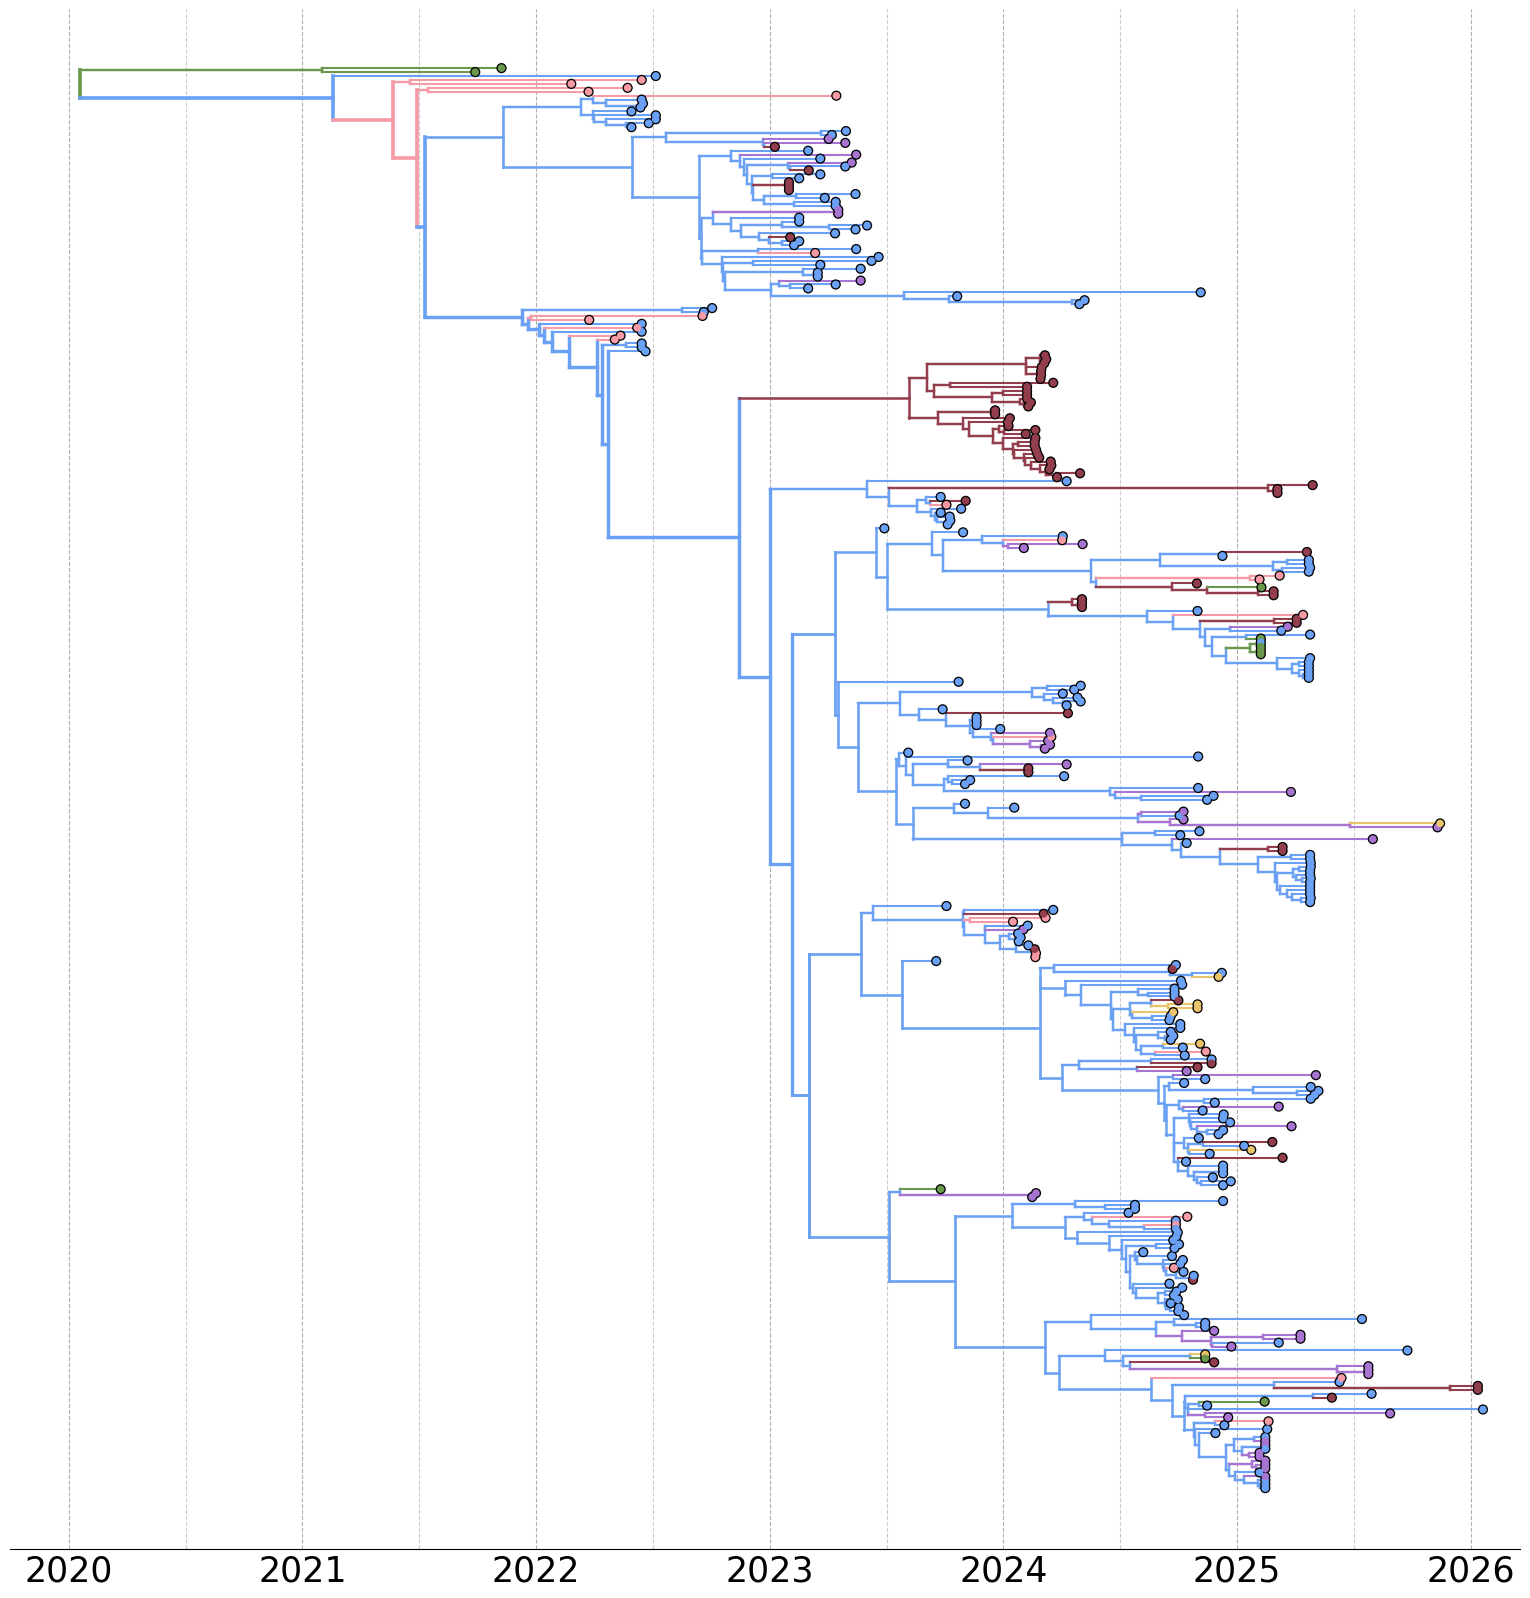

In [55]:
plot_tree("host", tree, 2026.0520547945205, "../H5N5-seabird-phylo/SERAPHIM/plots/baltic_A6-concat-gen_2026-08-04_host.png", h5n5_host_colors)

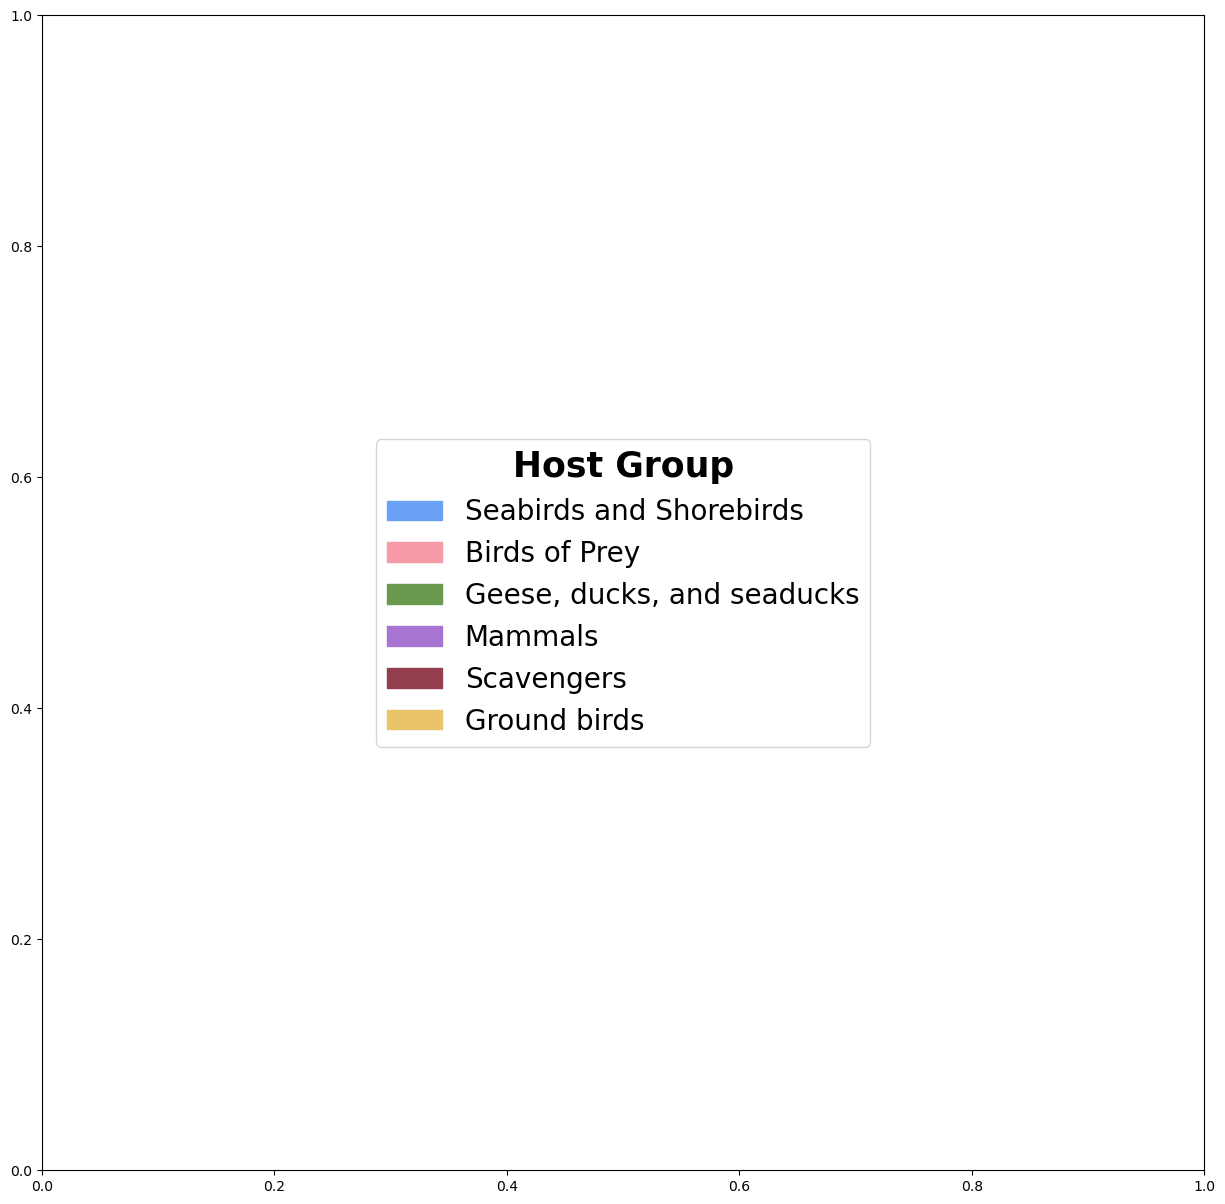

In [61]:
# Plot the legend

# If you want a separate legend

fig, ax = plt.subplots(figsize=(15, 15))

# colors = {"europe":"#ffaaaa",
#       "east-canada":"#95b8d1",
#       "northeast-us":"#f7df7d",
#       "north-canada":"#ba9cc9",
#       "northwest-us":"#94bf73",
#       "asia":"#b09a6e"
#      }

colors = {"seab":"#6AA1F4",
          "bdpr":"#F69BA6",
          "gds":"#6A994E",
          "mammal":"#A874D2",
          "scav":"#923E4D",
          "grdbd":"#E9C46A"
 #         "other":"#95A8B0"
         }

# labels = {"europe":"Europe",
#           "east-canada":"East Canada",
#           "northeast-us":"Northeast U.S.",
#           "north-canada":"North Canada",
#           "northwest-us":"Northwest U.S.",
#           "asia":"Asia"
#          }

labels = {"seab":"Seabirds and Shorebirds",
          "bdpr":"Birds of Prey",
          "gds":"Geese, ducks, and seaducks",
          "mammal":"Mammals",
          "scav":"Scavengers",
          "grdbd":"Ground birds"
         # "other":"#95A8B0"
         }

legend_handles = [Patch(color=color, label=labels[host]) for host, color in colors.items()]
legend = ax.legend(handles=legend_handles, title="Host Group", loc="center", fontsize=20)
legend.get_title().set_fontweight("bold")
plt.setp(legend.get_title(),fontsize=25)

plt.savefig("../H5N5-seabird-phylo/SERAPHIM/plots/host_legend.png")
plt.show()